In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
sns.set_style("whitegrid")
SAMPLE_SIZE = 12000

In [9]:
df=pd.read_csv("twitter_training.csv",header=None, names=["TweetID", "Entity", "Sentiment", "Text"])

In [10]:
df

,TweetID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [7]:
df.shape

(74681, 4)

In [11]:
df["Sentiment"].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [12]:
df["Text"].isnull().sum()

np.int64(686)

In [13]:
df = df.dropna(subset=["Text"])
df = df[df["Sentiment"].isin(["Positive", "Negative", "Neutral"])].copy()
df["Sentiment"] = df["Sentiment"].str.lower()

In [14]:
if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    frac = SAMPLE_SIZE / len(df)
    parts = [g.sample(frac=frac, random_state=42) for _, g in df.groupby("Sentiment")]
    df = pd.concat(parts, ignore_index=True)

In [15]:
print("\nWorking class distribution:\n", df["Sentiment"].value_counts())
print("\nClass distribution (%):\n", (df["Sentiment"].value_counts(normalize=True) * 100).round(1))


Working class distribution:
 Sentiment
negative    4390
positive    4055
neutral     3555
Name: count, dtype: int64

Class distribution (%):
 Sentiment
negative    36.6
positive    33.8
neutral     29.6
Name: proportion, dtype: float64


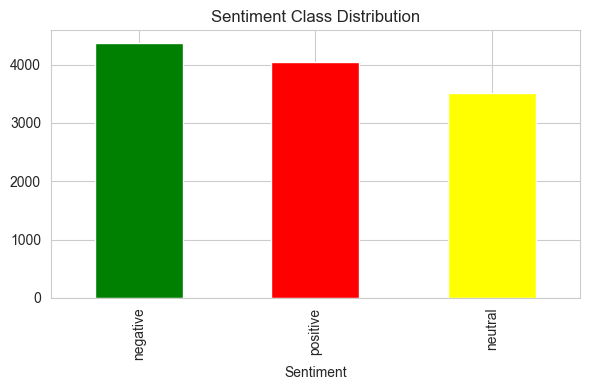

In [27]:
plt.figure(figsize=(6, 4))
df["Sentiment"].value_counts().plot(kind="bar", color=["green", "red", "yellow"])
plt.title("Sentiment Class Distribution")
plt.tight_layout()
#plt.savefig("sentiment_distribution.png")
plt.show()


In [17]:
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)      # strip URLs
    t = re.sub(r"@\w+", " ", t)                   # strip @mentions
    t = re.sub(r"[^a-z\s]", " ", t)               # strip punctuation/numbers
    t = re.sub(r"\s+", " ", t).strip()
    return t


In [18]:
df["clean_text"] = df["Text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0]


In [19]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df["clean_text"])
y = df["Sentiment"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
models = {
    "MultinomialNB": MultinomialNB(),
    "LinearSVC": LinearSVC(),
}

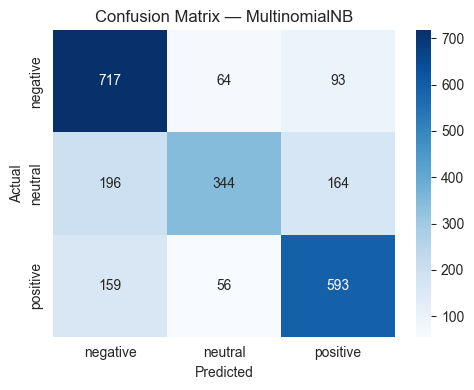

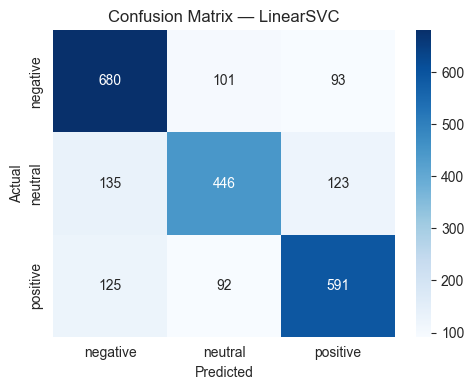

In [22]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, average="macro"),
        "recall": recall_score(y_test, preds, average="macro"),
        "f1": f1_score(y_test, preds, average="macro"),
    }
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",  xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    #plt.savefig(f"confusion_matrix_{name}.png")
    plt.show()



In [23]:
print("\n=== MODEL EVALUATION ===")
print(pd.DataFrame(results).T.round(3))



=== MODEL EVALUATION ===
               accuracy  precision  recall     f1
MultinomialNB     0.693      0.703   0.681  0.680
LinearSVC         0.720      0.718   0.714  0.715


In [24]:
print("""
DISCUSSION — why is recall important here?
Missing a genuinely negative tweet (a false negative) means a brand or
support team never sees a real complaint, which is more costly than
occasionally over-flagging a neutral tweet as negative (a false positive
that just gets a human to double-check). So recall on the "negative" class
specifically is prioritised over precision.
""")


DISCUSSION — why is recall important here?
Missing a genuinely negative tweet (a false negative) means a brand or
support team never sees a real complaint, which is more costly than
occasionally over-flagging a neutral tweet as negative (a false positive
that just gets a human to double-check). So recall on the "negative" class
specifically is prioritised over precision.



In [25]:
best_model_name = max(results, key=lambda k: results[k]["f1"])
model = models[best_model_name]
preds = model.predict(X_test)
test_texts = df.loc[y_test.index, "Text"]
mis_idx = np.where(preds != y_test.values)[0]
print(f"\nBest model: {best_model_name}. Sample misclassifications:")
for i in mis_idx[:5]:
    print(f' - "{test_texts.values[i][:100]}" | actual={y_test.values[i]} predicted={preds[i]}')

#print("\nSentiment analysis complete.")


Best model: LinearSVC. Sample misclassifications:
 - "Legit tho the concern is that if the vaccine Johnson & Johnson makes I'm unlikely to get it SINCE TH" | actual=negative predicted=neutral
 - "This is impressive!" | actual=negative predicted=positive
 - "Let's discuss the stupidity that is @ EASPORTSFIFA! They had the courage to include this message in " | actual=negative predicted=positive
 - "WTF, look at the size of it!!!." | actual=negative predicted=neutral
 - "a" | actual=neutral predicted=negative
